In [118]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import re
from tqdm import tqdm

from skimage.filters import threshold_niblack, threshold_sauvola
from skimage.morphology import remove_small_objects

In [119]:
image_dir = r'C:\V\sem_6_notes\DL_MedicalImage_processing\DigitalRetinaImages\DRIVE\training\images'


gt_dir = r'C:\V\sem_6_notes\DL_MedicalImage_processing\DigitalRetinaImages\DRIVE\training\1st_manual'

fov_dir = r'C:\V\sem_6_notes\DL_MedicalImage_processing\DigitalRetinaImages\DRIVE\training\mask'

print("Images:", len(os.listdir(image_dir)))
print("GT Masks:", len(os.listdir(gt_dir)))
print("FOV Masks:", len(os.listdir(fov_dir)))

Images: 20
GT Masks: 20
FOV Masks: 20


In [120]:
def sensitivity_score(pred, gt):
    TP = np.logical_and(pred, gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    return TP / (TP + FN + 1e-8)

def specificity_score(pred, gt):
    TN = np.logical_and(~pred, ~gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    return TN / (TN + FP + 1e-8)

def dice_score(pred, gt):
    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    return 2 * TP / (2 * TP + FP + FN + 1e-8)

def extract_thin_vessels(gt_mask):
    kernel = np.ones((3,3), np.uint8)
    eroded = cv2.erode(gt_mask.astype(np.uint8), kernel, iterations=1)
    thin = gt_mask.astype(np.uint8) - eroded
    return thin.astype(bool)

In [121]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

def preprocess_green(green):
    enhanced = clahe.apply(green)
    enhanced = cv2.GaussianBlur(enhanced, (3,3), 0)
    return enhanced

In [143]:
def apply_niblack(image):
    thresh = threshold_niblack(image, window_size=25, k=-0.25)
    binary = image < thresh
    binary = remove_small_objects(binary, min_size=40)
    return binary

def apply_sauvola(image):
    thresh = threshold_sauvola(image, window_size=25, k=0.1)
    binary = image < thresh
    binary = remove_small_objects(binary, min_size=40)
    return binary

In [144]:
filename = sorted(os.listdir(image_dir))[0]
img_id = re.findall(r'\d+', filename)[0]

img = cv2.imread(os.path.join(image_dir, filename))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gt = cv2.imread(os.path.join(gt_dir, f"{img_id}_manual1.gif"), 0) > 0
fov = cv2.imread(os.path.join(fov_dir, f"{img_id}_training_mask.gif"), 0) > 0

green = img_rgb[:, :, 1]
pre = preprocess_green(green)

pred_nib = apply_niblack(pre)
pred_sau = apply_sauvola(pre)

pred_nib &= fov
pred_sau &= fov
gt &= fov

print("Sauvola Sensitivity:", sensitivity_score(pred_sau, gt))
print("Niblack Sensitivity:", sensitivity_score(pred_nib, gt))

Sauvola Sensitivity: 0.6806490872208192
Niblack Sensitivity: 0.9459229208921112


C:\Users\ROG\AppData\Local\Temp\ipykernel_25936\1907289081.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)
C:\Users\ROG\AppData\Local\Temp\ipykernel_25936\1907289081.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, mi

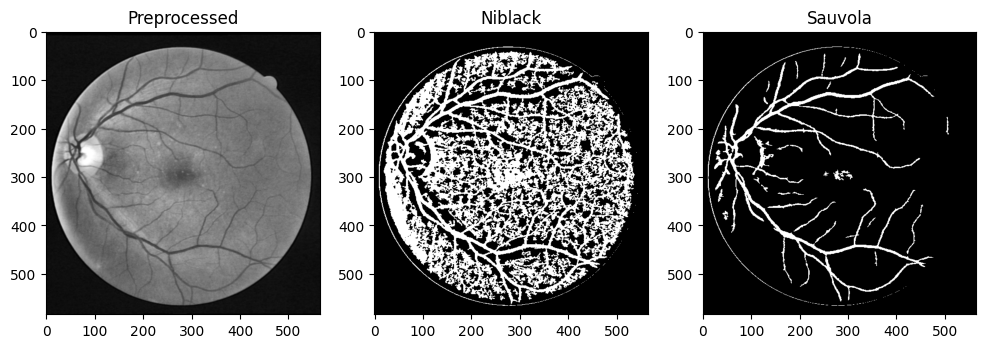

In [145]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(pre, cmap='gray')
plt.title("Preprocessed")

plt.subplot(1,3,2)
plt.imshow(pred_nib, cmap='gray')
plt.title("Niblack")

plt.subplot(1,3,3)
plt.imshow(pred_sau, cmap='gray')
plt.title("Sauvola")

plt.show()

In [146]:
sens_sau_list, sens_nib_list = [], []
dice_sau_list, dice_nib_list = [], []

thin_sau_list, thin_nib_list = [], []

for filename in tqdm(sorted(os.listdir(image_dir))):

    img_id = re.findall(r'\d+', filename)[0]

    img = cv2.imread(os.path.join(image_dir, filename))
    gt  = cv2.imread(os.path.join(gt_dir, f"{img_id}_manual1.gif"), 0)
    fov = cv2.imread(os.path.join(fov_dir, f"{img_id}_training_mask.gif"), 0)

    if img is None or gt is None or fov is None:
        print("Skipping:", filename)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt  = gt > 0
    fov = fov > 0

    green = img_rgb[:, :, 1]
    pre = preprocess_green(green)

    pred_nib = apply_niblack(pre)
    pred_sau = apply_sauvola(pre)

    pred_nib &= fov
    pred_sau &= fov
    gt &= fov

    sens_sau_list.append(sensitivity_score(pred_sau, gt))
    sens_nib_list.append(sensitivity_score(pred_nib, gt))

    dice_sau_list.append(dice_score(pred_sau, gt))
    dice_nib_list.append(dice_score(pred_nib, gt))

    thin_gt = extract_thin_vessels(gt)

    thin_sau_list.append(sensitivity_score(pred_sau, thin_gt))
    thin_nib_list.append(sensitivity_score(pred_nib, thin_gt))

print("\n===== FINAL RESULTS =====")
print("Sauvola Sensitivity :", np.mean(sens_sau_list))
print("Niblack Sensitivity :", np.mean(sens_nib_list))

print("Sauvola Dice        :", np.mean(dice_sau_list))
print("Niblack Dice        :", np.mean(dice_nib_list))

print("Sauvola Thin Sens   :", np.mean(thin_sau_list))
print("Niblack Thin Sens   :", np.mean(thin_nib_list))

  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\ROG\AppData\Local\Temp\ipykernel_25936\1907289081.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=40)
C:\Users\ROG\AppData\Local\Temp\ipykernel_25936\1907289081.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bi


===== FINAL RESULTS =====
Sauvola Sensitivity : 0.6664707581273823
Niblack Sensitivity : 0.9339562060026505
Sauvola Dice        : 0.6724352775239903
Niblack Dice        : 0.35899576308018716
Sauvola Thin Sens   : 0.5252414658599499
Niblack Thin Sens   : 0.9050591394716561


We can observe that the sensitivity is not aligning with the actual images i get at ouput i.e., fo sauvola, if used k = 0.01, we'll sensitivty = 0.90 easily but the output vessels become too distoreted and noisy and somewhat start to look like nilback output. Same goes for changing K value for Nilback.